# Introduction to Machine Learning: Illustrated Principles
## Notebook to accompany Chapter 7: Margin-Based Classification

<div class="alert alert-success" style="border-left: 5px solid #28a745;">
    
### **SOLUTIONS**

## Overview

This notebook set deals with the [Banknote Authentication](https://archive.ics.uci.edu/dataset/267/banknote+authentication) dataset.

Our goal is to classify banknotes by whether they are genuine or forged using support vector machines.

In [1]:
## These are the only libraries you should need
import numpy as np
import matplotlib.pyplot as plt


# below line just to make figures larger
#plt.rcParams["figure.figsize"] = (20,10)

### Dataset
Each data point in the dataset corresponds to an image of a banknote.  The label, $y$, is whether the note was genuine ($y=0$) or forged ($y=1$).  For this problem set, we will only be loking at the first two features: the variance and the skewness of the coefficients of a wavelet representation of the image.

The code below loads in both a training dataset (`train`) and a testing dataset (`test`).  Each has a `.X` and `.Y` field: numpy arrays of the $X$ and $Y$ matrices.  You can view the names of the features as `train.featnames`.

In [2]:
import sys; sys.path.insert(0, '../..') # path to dataset.py (adjust if you have moved this file or dataset.py)
from dataset import loaddataset

#adjust the directory below if you have moved either the dataset files or this notebook
datasetdir = '../../datasets/' 

train = loaddataset(datasetdir+'banknote-train')
test = loaddataset(datasetdir+'banknote-test')

### Data Pre-processing
We select the first two features, and, as common, we do z-score normalization (see previous chapters' notebooks or chapter 9): replace each feature with the number of standard deviations the raw feature is from the mean in the trainging test.  Treat these new X matrices as the "raw features" for the purposes below.

In [3]:
# use only the first 2 features:
i0,i1 = (0,1)
train.X = train.X[:,[i0,i1]]
train.featnames = [train.featnames[i] for i in [i0,i1]]
test.X = test.X[:,[i0,i1]]
test.featnames = [test.featnames[i] for i in [i0,i1]]

# z-score normalize
mu = np.mean(train.X,axis=0)
stddev = np.std(train.X,axis=0)
train.X = (train.X-mu)/stddev
test.X = (test.X-mu)/stddev

### Visualization
Below is a function that will plot the data and (optionally) a decision function.  The decision function is a function that takes in an m-by-2 matrix of m points and returns the discriminant values for each of the m points as an m-dimensional vector.

In [4]:
def drawdiscriminant(ax,f,npts=50):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xs,ys = np.mgrid[xlim[0]:xlim[1]:(npts*1j),ylim[0]:ylim[1]:(npts*1j)]
    xys = np.vstack([xs.ravel(),ys.ravel()]).T
    ax.contour(xs,ys,f(xys).reshape(xs.shape),levels=[-1,0,1],colors=['C0','black','C1'],linestyles=['--','-','--'])
    
def plotdata(X,Y,f=None,ax=None):
    if ax is None:
        ax = plt.gca()
    ax.plot(X[Y<=0,0],X[Y<=0,1],'o',markerfacecolor='none')
    ax.plot(X[Y> 0,0],X[Y> 0,1],'+')
    if 'train' in globals():
        ax.set_xlabel(train.featnames[0])
        ax.set_ylabel(train.featnames[1])
        ax.legend(train.ycats);
    if f is not None:
        drawdiscriminant(ax,f)

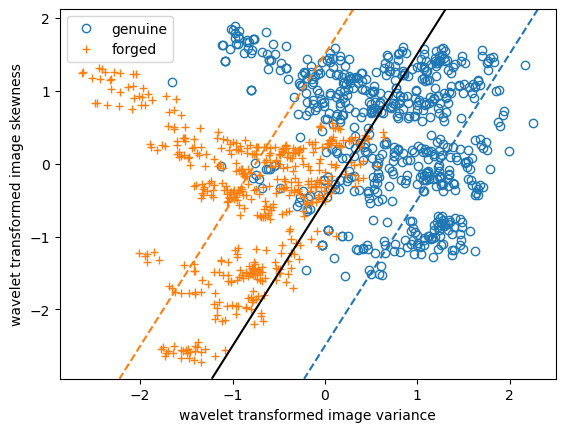

In [5]:
def lineardisc(X,w,b):
    return X@w + b

# example plotting without any discriminant:
# plotdata(train.X,train.Y)

# example plotting with a linear discriminant using arbitrarily chosen w and b:
examplew = np.array([-1.0,0.5])
exampleb = 0.25
plotdata(train.X,train.Y,lambda X : lineardisc(X,examplew,exampleb))

### Quadratic Programming Solver
Below is a function that serves as the interface to a quadratic programming solver.  Essentially it just passes along its arguments to `solve_qp` from the `qpsolvers` package.  It uses the cvxopt solver.  If your version does not have that solver, you can select a different one, but it must support problems that are not strictly positive definite.  You can install `qpsolvers` with the needed solvers with `pip install qpsolvers[open_source_solvers]` or `pip install qpsolvers[cvxopt]`.

Note that constraints of the form $Gx \ge h$ are the same as $-Gx \le -h$.

In [6]:
def solveqp(P,q,G=None,h=None,A=None,b=None,lb=None,ub=None):
    # Solves quadratic program
    #
    #    minimize (1/2) x' P x + q' x
    #    subject to
    #              G x <= h [element-wise]
    #              A x = b
    #              lb <= x <= ub [element-wise]
    #
    # Returns x that solves this minimization problem or None if 
    # no solution exists
    #
    # To omit any one of the constraints,
    # leave the corresponding coefficients as None

    def fix(z,ndim):
        if z is None:
            return None
        if ndim==1:
            return np.atleast_1d(z).astype(float)
        if ndim==2:
            return np.atleast_2d(z).astype(float)

    from qpsolvers import solve_qp
    x = solve_qp(fix(P,2),fix(q,1),fix(G,2),fix(h,1),fix(A,2),fix(b,1),fix(lb,1),fix(ub,1),solver='cvxopt')
    return x

## Question 1: **Linear SVM**
---
> **part a** Complete the following function to learn a linear SVM.  The code that follows will plot the result on the training data for C=0.1.
>
> *Note*: the classes are encoded as 0 and 1 in the Y vector, not -1 and +1
---

In [7]:
def learnlinearsvm(X,Y,C):
    # Function accepts m-by-n matrix X and m-dimensional vector Y (with values 0 and 1)
    # C is the scalar controlling the slack variable penalty
    # returns the pair (w,b) where w is an n-dimensional vector and b is a scalar
    
    m,n = X.shape
    Idiag = np.zeros(1+n+m)
    Idiag[1:(1+n)] = 1
    I = np.diag(Idiag)
    
    q = np.zeros(1+n+m)
    q[1+n:] = C

    Yposneg = (2*Y-1)[:,None]
    M = np.hstack((Yposneg,X*Yposneg,np.eye(m)))
    M = np.vstack((M,np.hstack((np.zeros((m,n+1)),np.eye(m)))))
    h = np.ones(2*m)
    h[m:] = 0
    z = solveqp(I,q,-M,-h)
    w = z[1:(1+n)]
    b = z[0]
    return w,b

w = [-1.688 -1.029], b = -0.265


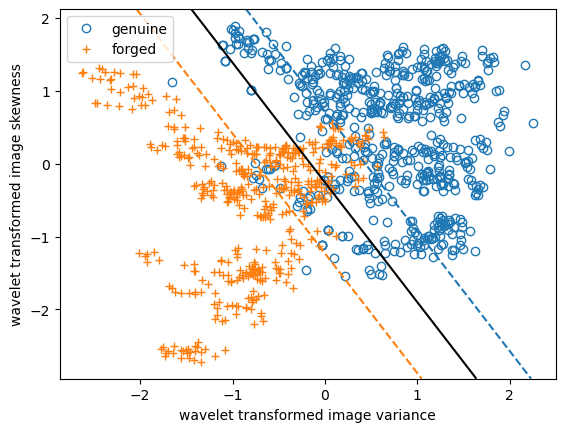

In [8]:
linearsvmsol = learnlinearsvm(train.X,train.Y,0.1)
with np.printoptions(precision=3,suppress=True):
    print(f'w = {linearsvmsol[0]}, b = {linearsvmsol[1]:.3f}')
plotdata(train.X,train.Y,lambda X : lineardisc(X,*linearsvmsol))

---
> **part b** Use 5-fold cross validation to select C for this linear SVM.
>
> Select C from a range from $10^{-3}$ to $10^{3}$.  Select a suitable number of points (at least 10), arranged evenly on a logarithmic scale.
> Report the chosen C and the error (misclassification rate) of the resulting classifier on both the training and testing data.
---

In [9]:
def xvalid(trainfn, testfn, X, Y, k=5):
    allind = np.arange(X.shape[0])
    foldinds = np.array_split(allind,k)
    totalerr = 0
    for validind in foldinds:
        trainind = np.setdiff1d(allind,validind)
        w = trainfn(X[trainind],Y[trainind])
        totalerr += testfn(X[validind],Y[validind],w)*len(validind)
    return totalerr/X.shape[0]

def testlineardisc(X,Y,w):
    return np.mean(Y != (lineardisc(X,*w)>0).astype(int))

Cs = np.logspace(-3,3,13)
besterr = None
for C in Cs:
    err = xvalid(lambda X, Y: learnlinearsvm(X,Y,C),testlineardisc,train.X,train.Y,5)
    if besterr is None or besterr>err:
        besterr = err
        bestC = C

w,b = learnlinearsvm(train.X,train.Y,bestC)
trainerr = testlineardisc(train.X,train.Y,(w,b))
testerr = testlineardisc(test.X,test.Y,(w,b))

print(f'C = {bestC}')
print(f'training error = {trainerr}')
print(f'testing error = {testerr}')

    

C = 0.03162277660168379
training error = 0.11577028258887875
testing error = 0.13454545454545455


## Question 2: **Non-linear SVM**
---
> **part a** Complete the following function to learn a non-linear SVM.
>
> *Note*: the classes are encoded as 0 and 1 in the Y vector, not -1 and +1.  Read the specifications of inputs and outputs carefully.
---

In [10]:
def learnkernelsvm(X,Y,C,kernel):
    # Function accepts m-by-n matrix X and m-dimensional vector Y (with values 0 and 1)
    # C is the scalar controlling the slack variable penalty
    # kernel is a function that accepts two X matrices, X1 and X2, of sizes
    #   m1-by-n and m2-by-n and returns the kernel matrix of size m1-by-m2
    #   where the i,j element is the kernel applied to the ith row X1 and
    #   jth row of X2.
    #
    # returns a tuple of (k,a,b,x,y)
    #    where k is kernel
    #          a is the set of weights for the support vectors
    #          b is the offset
    #          x is a p-by-n matrix of the p support vectors
    #          y is a p vector of the labels of the support vectors (as +1 or -1)
    # 
    m,n = X.shape
    K = kernel(X,X)
    Yposneg = 2*Y-1
    Yposneg = Yposneg.astype(float)
    G = K*Yposneg[:,None]*Yposneg[None,:]
    a = solveqp(G,-np.ones(m),lb = np.zeros(m),ub = np.ones(m)*C,A=Yposneg[None,:], b = np.array([0.0]))

    aeps = C*1e-6
    mind = (a>aeps) * (a<C-aeps)
    if np.sum(mind)==0:
        print(np.max(a[a<C/2]))
        print(C-np.min(a[a>C/2]))
    ypred = kernelsvmdisc(X[mind],(kernel,a,0,X,Yposneg))
    b = np.mean(Yposneg[mind] - ypred)
    
    supportvects = a>aeps
    return kernel,a[supportvects],b,X[supportvects],Yposneg[supportvects]

def kernelsvmdisc(X,params):
    # Function accepts a m-by-n matrix of the testing points
    #    and params which is the tuple returned by learnkernelsvm
    #
    # returns an m vector of the discriminant at each of the testing points
    kernel,a,b,svX,svY = params
    K = kernel(X,svX)
    return (a[None,:]*svY[None,:]*K).sum(axis=1) + b

---
> **part b** Complete the definition of a linear kernel below and verify that the learned function is the same as in question 1a
---

In [11]:
def linearkernel(X1,X2):
    # X1 and X2 are sizes m1-by-n and m2-by-n
    # returns K of size m1-by-m2 where K_ij is the inner product of X1[i,:] and X2[j,:]
    return (X1[:,None,:]*X2[None,:,:]).sum(axis=2)

def calclinearwb(params): # only valid if kernel is linearkernel
    # takes in the tuple returned from learnkernelsvm
    # returns tuple of (w,b) where w and b are the weights
    # for the equivalent linear classifier
    k,a,b,x,y = params
    return ((a*y)[:,None]*x).sum(axis=0), b

w = [-1.688 -1.029], b = -0.264


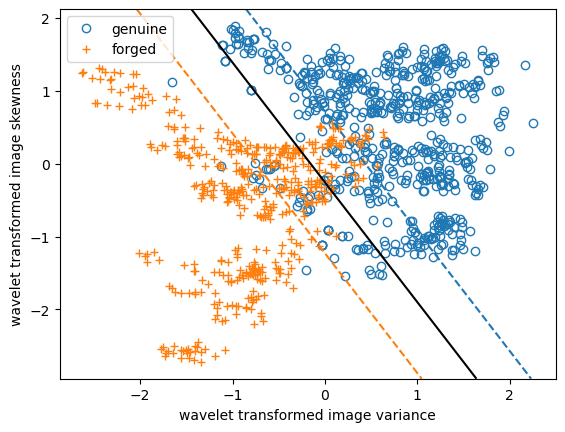

In [12]:
params = learnkernelsvm(train.X,train.Y,0.1,linearkernel)
w,b = calclinearwb(params)
with np.printoptions(precision=3,suppress=True):
    print(f'w = {w}, b = {b:.3f}')
plotdata(train.X,train.Y,lambda X : kernelsvmdisc(X,params))

---
> **part c** Implement the polynomial and RBF kernel functions below and verify they work visually with the code that follows
---

In [13]:
def polykernel(X1,X2,d,c):
    return ((X1[:,None,:]*X2[None,:,:]).sum(axis=2)+c)**d
    
def rbfkernel(X1,X2,gamma):
    return np.exp(-gamma*((X1[:,None,:]-X2[None,:,:])**2).sum(axis=2))

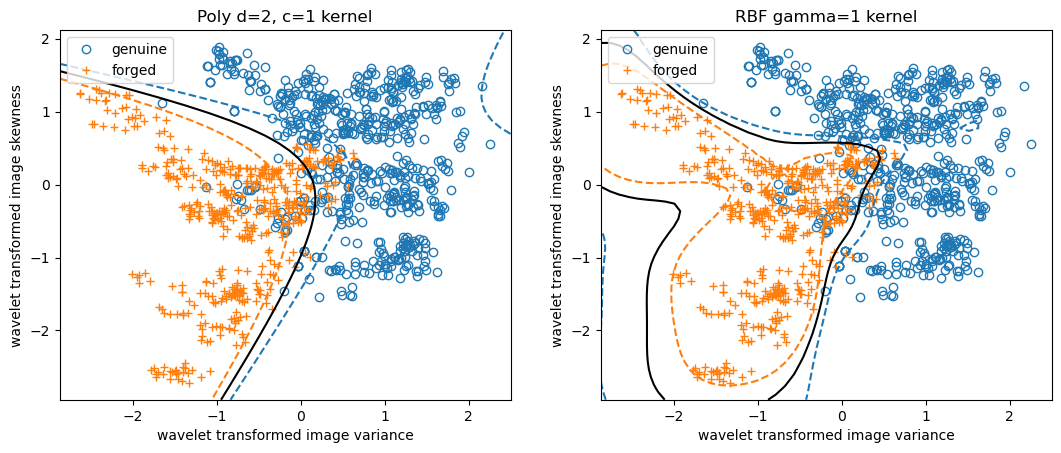

In [14]:
## code to generate and plot example SVMs for polynomial and RBF kernels

# define the two kernels with specific parameters:
poly21kernel = lambda X1,X2 : polykernel(X1,X2,d=2,c=1)
rbf1kernel = lambda X1,X2 : rbfkernel(X1,X2,gamma=1)

# learn the svms:
polyparams = learnkernelsvm(train.X,train.Y,C=100,kernel=poly21kernel)
rbfparams = learnkernelsvm(train.X,train.Y,C=100,kernel=rbf1kernel)

# plot:
fs = plt.rcParams.get('figure.figsize')
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(fs[0]*2,fs[1]))
            
plotdata(train.X,train.Y,lambda X : kernelsvmdisc(X,polyparams),ax1)
ax1.set_title('Poly d=2, c=1 kernel')
plotdata(train.X,train.Y,lambda X : kernelsvmdisc(X,rbfparams),ax2)
ax2.set_title('RBF gamma=1 kernel');

---
> **part d** Use 5-fold cross-validation to select the kernel parameters and C.  Select C from the set {$10^{-2}$, $10^{-1}$, $1$, $10$}.  Try both the polynomial kernel with degrees from 1 to 4 and c values from {$10^{-1}$,$1$,$10$} and the RBF kernel with gammas from the set {$10^{-2}$, $10^{-1}$, $1$, $10$}.
>
> Report the chosen C and kernel parameters as well as the cross-validation loss.
---

In [15]:
def testkernelsvm(X,Y,w):
    return np.mean(Y != (kernelsvmdisc(X,w)>0).astype(int))

In [16]:
polykernels = [('poly',polykernel,[dict(d=d,c=c) for d in range(1,5) for c in [0.1,1,10]])]
rbfkernels = [('rbf',rbfkernel,[dict(gamma=float(g)) for g in np.logspace(-2,1,4)])]
kernels = polykernels+rbfkernels
Cs = [0.001,0.01,0.1,1,10]

np.seterr(all='raise')
besterr = None
for C in Cs:
    for kname,kernel,hyperparams in kernels:
        for hyper in hyperparams:
            k = lambda X1,X2 : kernel(X1,X2,**hyper)
            err = xvalid(lambda XX,YY: learnkernelsvm(XX,YY,C,k),
                         testkernelsvm, train.X, train.Y, 5)
            if besterr is None or err<besterr:
                besterr = err
                bestC = C
                bestkname = kname
                bestk = kernel
                besthyper = hyper
                picked='*'
            else:
                picked=''
            print(f'{kname} C={C} {hyper} => {err:3.4} {picked}')

poly C=0.001 {'d': 1, 'c': 0.1} => 0.1568 *
poly C=0.001 {'d': 1, 'c': 1} => 0.1568 
poly C=0.001 {'d': 1, 'c': 10} => 0.1568 
poly C=0.001 {'d': 2, 'c': 0.1} => 0.4175 
poly C=0.001 {'d': 2, 'c': 1} => 0.1395 *
poly C=0.001 {'d': 2, 'c': 10} => 0.09663 *
poly C=0.001 {'d': 3, 'c': 0.1} => 0.2434 
poly C=0.001 {'d': 3, 'c': 1} => 0.1076 
poly C=0.001 {'d': 3, 'c': 10} => 0.08569 *
poly C=0.001 {'d': 4, 'c': 0.1} => 0.2789 
poly C=0.001 {'d': 4, 'c': 1} => 0.09025 
poly C=0.001 {'d': 4, 'c': 10} => 0.07657 *
rbf C=0.001 {'gamma': 0.01} => 0.4448 
rbf C=0.001 {'gamma': 0.1} => 0.4448 
rbf C=0.001 {'gamma': 1.0} => 0.4448 
rbf C=0.001 {'gamma': 10.0} => 0.4448 
poly C=0.01 {'d': 1, 'c': 0.1} => 0.1203 
poly C=0.01 {'d': 1, 'c': 1} => 0.1203 
poly C=0.01 {'d': 1, 'c': 10} => 0.1203 
poly C=0.01 {'d': 2, 'c': 0.1} => 0.1422 
poly C=0.01 {'d': 2, 'c': 1} => 0.08569 
poly C=0.01 {'d': 2, 'c': 10} => 0.08842 
poly C=0.01 {'d': 3, 'c': 0.1} => 0.1231 
poly C=0.01 {'d': 3, 'c': 1} => 0.08204 
po

In [17]:
print(f'Chose kernel {bestkname} with hyperparameters {besthyper} and C={bestC}.  Validation error = {float(besterr)}')

Chose kernel rbf with hyperparameters {'gamma': 1.0} and C=1.  Validation error = 0.06472196900638104


---
> **part e**  Using the hyper-parameters chosen above, train an SVM on the entire training data set.  Plot the decision surface (like part c) and report the *testing* error of the resulting classifier.
---

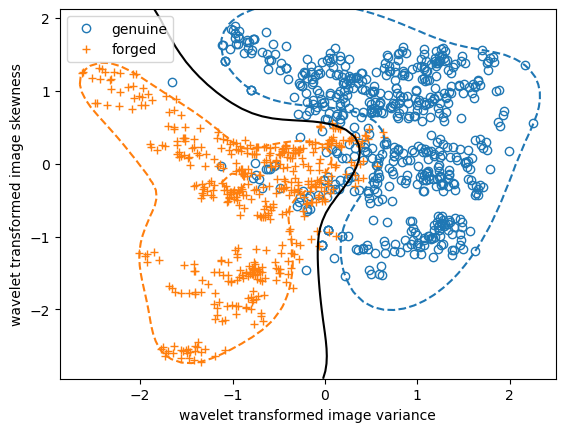

In [18]:
myk = lambda X1,X2 : bestk(X1,X2,**besthyper)
params = learnkernelsvm(train.X,train.Y,bestC,myk)
plotdata(train.X,train.Y,lambda X : kernelsvmdisc(X,params))

In [19]:
print('testing error:',testkernelsvm(test.X,test.Y,params))

testing error: 0.06909090909090909
